## Data processing code. 

1. Look at data, exploration
2. train dataset, machine learning. 
3. Model is ready!

In [43]:
import sklearn as sk
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV




In [44]:
# Load the dataset 
data = pd.read_csv('ect_remission_synthetic.csv')
# Display the first few rows of the dataset
print(data.head())

# Print column names
print(data.columns)

# Print number of females and males 
Sex_counts = data['Sex'].value_counts()

print(f"Number of females: {Sex_counts.get('Female', 0)}")
print(f"Number of males: {Sex_counts.get('Male', 0)}")

      Sex AgeGroup MaritalStatus    Education DepressionType  \
0  Female    61-70     Unmarried    >12 years        Bipolar   
1    Male    31-40       Married    >12 years       Unipolar   
2    Male    51-60     Unmarried  10-12 years        Bipolar   
3  Female    61-70       Married    >12 years       Unipolar   
4  Female    41-50     Unmarried     ≤9 years       Unipolar   

   PsychoticFeatures  SubstanceUse  PersonalityDisorder  AnxietyDisorder  \
0                  0             0                    0                1   
1                  0             0                    0                0   
2                  0             0                    0                0   
3                  1             1                    0                1   
4                  1             0                    0                0   

  InitialSetting     Coercion     AntidepressantBeforeECT  Lithium  \
0      Inpatient    Voluntary   Not 0-3 months before ECT        0   
1      Inpatient  

In [45]:
#Neat way to display the variables, for master thesis. 
import pandas as pd

data = pd.read_csv("ect_remission_synthetic.csv")

rows = []

for column in data.columns:
    counts = data[column].value_counts().sort_index()

    first_row = True
    for category, count in counts.items():
        percentage = count / len(data) * 100

        if category == 0:
            category = "No"
        elif category == 1:
            category = "Yes"

        variable_name = column if first_row else ""
        first_row = False

        rows.append([variable_name, category, count, f"{percentage:.1f}\\%"])

latex = r"""
\begin{longtable}{llrr}
\caption{Demographic, clinical, and treatment-related characteristics of the synthetic dataset.}
\label{tab:datasetcharacteristics}\\
\toprule
\textbf{Variable} & \textbf{Category} & \textbf{Count} & \textbf{Percentage} \\
\midrule
\endfirsthead

\toprule
\textbf{Variable} & \textbf{Category} & \textbf{Count} & \textbf{Percentage} \\
\midrule
\endhead

\midrule
\multicolumn{4}{r}{Continued on next page} \\
\midrule
\endfoot

\bottomrule
\endlastfoot
"""

current_variable = None

for variable, category, count, percentage in rows:
    latex += f"{variable} & {category} & {count} & {percentage} \\\\\n"

latex += r"\end{longtable}"

with open("dataset_characteristics.tex", "w", encoding="utf-8") as f:
    f.write(latex)

In [46]:
# Split into features and target, remission is what I want to predict
X = data.drop('Remission', axis=1)
y = data['Remission']

# Split into training ,validating and testing sets
X_train, X_valtest, y_train, y_valtest = train_test_split(X, y, test_size=0.3 ,random_state=42, stratify=y)
print(f"Training set size: {X_train.shape}, Testing set size: {X_valtest.shape}")

# Further split validation and testing sets
X_val, X_test, y_val, y_test = train_test_split(X_valtest, y_valtest, test_size=0.5, random_state=42, stratify=y_valtest)
print(f"Validation set size: {X_val.shape}, Testing set size: {X_test.shape}")



Training set size: (2339, 15), Testing set size: (1003, 15)
Validation set size: (501, 15), Testing set size: (502, 15)


### Data exploration
Goal is to gain an understanding of the data and its population. 

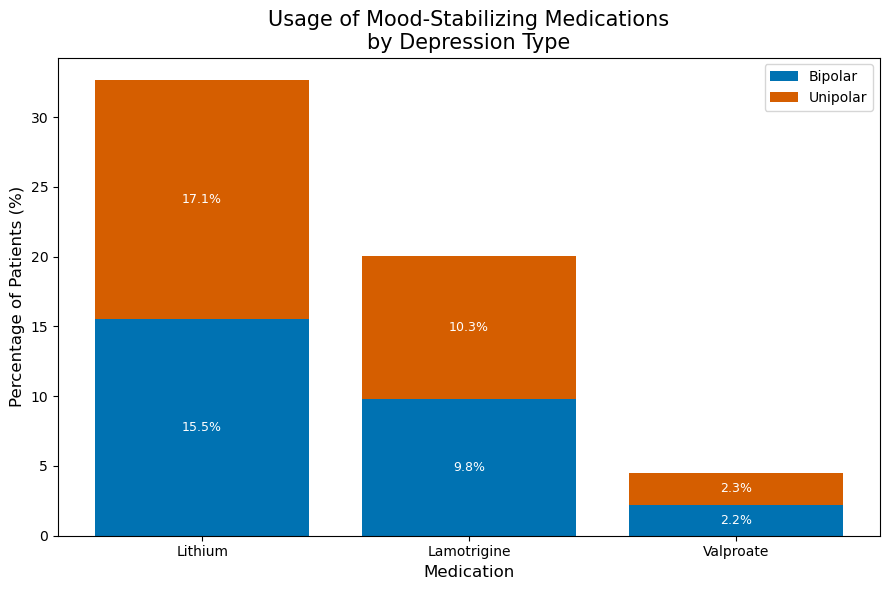

In [47]:
#Barcharts for master thesis. 
medications = ["Lithium", "Lamotrigine", "Valproate"]

bipolar = data[data["DepressionType"] == "Bipolar"]
unipolar = data[data["DepressionType"] == "Unipolar"]

bipolar_percentages = [
    bipolar[med].mean() * 100 for med in medications
]

unipolar_percentages = [
    unipolar[med].mean() * 100 for med in medications
]

x = np.arange(len(medications))

# Colorblind-safe colors
colors = ["#0072B2", "#D55E00"]

fig, ax = plt.subplots(figsize=(9, 6))

# Bottom bars (Bipolar)
bars1 = ax.bar(
    x,
    bipolar_percentages,
    label="Bipolar",
    color=colors[0]
)

# Top bars (Unipolar)
bars2 = ax.bar(
    x,
    unipolar_percentages,
    bottom=bipolar_percentages,
    label="Unipolar",
    color=colors[1]
)

for i, bar in enumerate(bars1):
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height / 2,
        f"{height:.1f}%",
        ha='center',
        va='center',
        fontsize=9,
        color='white'
    )

for i, bar in enumerate(bars2):
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bipolar_percentages[i] + height / 2,
        f"{height:.1f}%",
        ha='center',
        va='center',
        fontsize=9,
        color='white'
    )

ax.set_title(
    "Usage of Mood-Stabilizing Medications\nby Depression Type",
    fontsize=15
)

ax.set_xlabel("Medication", fontsize=12)
ax.set_ylabel("Percentage of Patients (%)", fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(medications)

ax.legend()

plt.tight_layout()
plt.show()




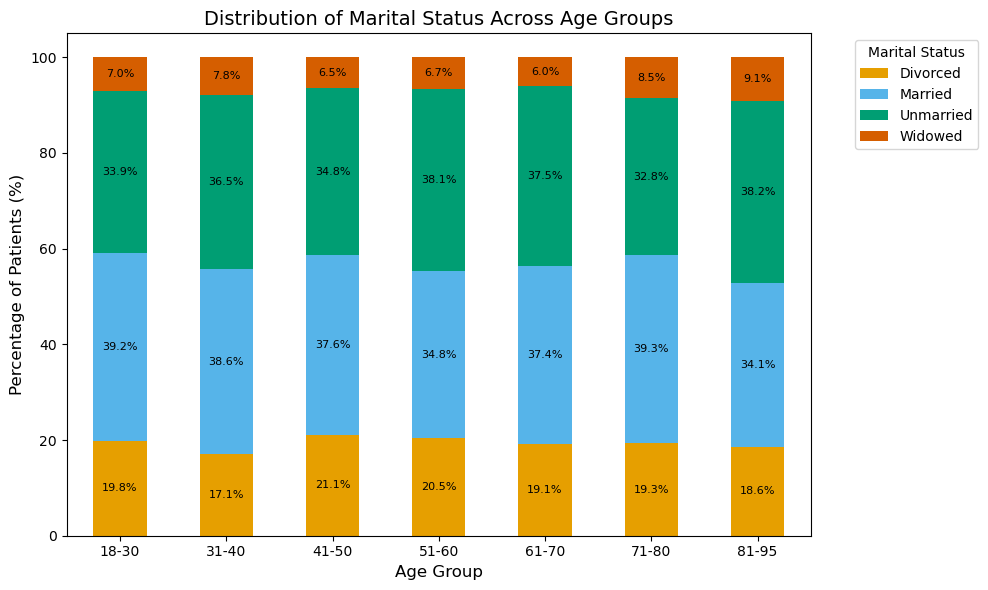

In [48]:
# Create percentage table
marital_by_age = pd.crosstab(
    data["AgeGroup"],
    data["MaritalStatus"],
    normalize='index'
) * 100

# Correct age order
age_order = [
    "18-30",
    "31-40",
    "41-50",
    "51-60",
    "61-70",
    "71-80",
    "81-95"
]

marital_by_age = marital_by_age.reindex(age_order)

# Colorblind-safe palette
colors = [
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#009E73",  # bluish green
    "#D55E00",  # vermillion
]

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))

marital_by_age.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color = colors [:len (marital_by_age.columns)]
)

for container in ax.containers:
    labels = []

    for bar in container:
        height = bar.get_height()

        # Only show labels for visible sections
        if height > 3:
            labels.append(f"{height:.1f}%")
        else:
            labels.append("")

    ax.bar_label(
        container,
        labels=labels,
        label_type='center',
        fontsize=8,
        color='black'
    )

ax.set_title(
    "Distribution of Marital Status Across Age Groups",
    fontsize=14
)

ax.set_xlabel("Age Group", fontsize=12)
ax.set_ylabel("Percentage of Patients (%)", fontsize=12)

ax.legend(
    title="Marital Status",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

## Choosing features to use

Before training I want to drop some features so that there is not so many questions on the web-application. Therefore I need to figure out which features contribute the most/are most important for the result. 

In [49]:
# Using one hot encoding for categorical variables ensures that no ordinal relationship is assumed between categories
categorical = [
    "Sex",
    "AgeGroup",
    "MaritalStatus",
    "Education",
    "DepressionType",
    "InitialSetting",
    "Coercion",
    "AntidepressantBeforeECT"
]

binary = [c for c in X.columns if c not in categorical]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical),
        ("bin", "passthrough", binary)
    ]
)

### Baseline model
Using logistic regression L1 Lasso for my first feature selection. This model works well with binary outcomes, which is what the regression feature is, and the dataset also contains a lot of binary features.

In [50]:
lasso_model = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", LogisticRegression(
        penalty="l1",
        solver="saga",
        max_iter=5000
    ))
])

lasso_model.fit(X_train, y_train)


,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('bin', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Extracting the features from the L1 Lasso


In [51]:
feature_names = (
    lasso_model.named_steps["prep"]
    .get_feature_names_out()
)

coefs = lasso_model.named_steps["clf"].coef_[0]

selected = feature_names[np.abs(coefs) > 0]
selected

array(['cat__Sex_Male', 'cat__AgeGroup_31-40', 'cat__AgeGroup_41-50',
       'cat__AgeGroup_51-60', 'cat__AgeGroup_61-70',
       'cat__AgeGroup_71-80', 'cat__AgeGroup_81-95',
       'cat__MaritalStatus_Married', 'cat__MaritalStatus_Unmarried',
       'cat__MaritalStatus_Widowed', 'cat__Education_>12 years',
       'cat__Education_≤9 years', 'cat__DepressionType_Unipolar',
       'cat__InitialSetting_Outpatient', 'cat__Coercion_Voluntary',
       'cat__AntidepressantBeforeECT_0-3 months and 3-6, not 6-9',
       'cat__AntidepressantBeforeECT_0-3 months, not 3-6',
       'cat__AntidepressantBeforeECT_Never',
       'cat__AntidepressantBeforeECT_Not 0-3 months before ECT',
       'bin__PsychoticFeatures', 'bin__SubstanceUse',
       'bin__PersonalityDisorder', 'bin__AnxietyDisorder', 'bin__Lithium',
       'bin__Lamotrigine', 'bin__Valproate'], dtype=object)

### Second model : Random forest. 
I also want to try the random forest model, as this captures non-linear effects and can capture interactions within the features. 

In [52]:
rf = Pipeline(steps=[
    ("prep", preprocessor),
    ("rf", RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42
    ))
])

rf.fit(X_train, y_train)

,steps,"[('prep', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('bin', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [53]:
importances = rf.named_steps["rf"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(10)

,feature,importance
0,cat__Sex_Male,0.070217
10,cat__Education_>12 years,0.059535
22,bin__AnxietyDisorder,0.054443
20,bin__SubstanceUse,0.053929
7,cat__MaritalStatus_Married,0.053894
8,cat__MaritalStatus_Unmarried,0.051823
18,cat__AntidepressantBeforeECT_Not 0-3 months be...,0.050498
12,cat__DepressionType_Unipolar,0.047889
13,cat__InitialSetting_Outpatient,0.043859
21,bin__PersonalityDisorder,0.040001


### Permutaion importance
This is a robust, model-agnostic technique which measures a features impact on a model by shuffling the values and observing if there is a drop in the models score. If there is a drop, it means that the feature is important. Bigger drop -> more important.

In [54]:
r = permutation_importance(
    rf, X_train, y_train,
    n_repeats=30,
    random_state=42,
    scoring="roc_auc"
)

perm_df = pd.DataFrame({
    "feature": X.columns,
    "importance": r.importances_mean
}).sort_values("importance", ascending=False)

perm_df.head(10)

,feature,importance
1,AgeGroup,0.274516
11,AntidepressantBeforeECT,0.143416
2,MaritalStatus,0.124527
3,Education,0.108493
8,AnxietyDisorder,0.058569
5,PsychoticFeatures,0.047775
0,Sex,0.046956
4,DepressionType,0.031920
6,SubstanceUse,0.030651
12,Lithium,0.023387


In [55]:
# --- 1. Get feature names after preprocessing ---
feature_names = lasso_model.named_steps["prep"].get_feature_names_out()

# --- 2. LASSO importance (absolute coefficients) ---
lasso_coefs = lasso_model.named_steps["clf"].coef_[0]
lasso_scores = np.abs(lasso_coefs)

# --- 3. Random Forest importance ---
rf_importance = rf.named_steps["rf"].feature_importances_

# --- 4. Permutation importance ---
perm_importance = r.importances_mean

# IMPORTANT: permutation was done on raw X, need same feature space
# So recompute permutation on transformed data instead:
from sklearn.inspection import permutation_importance

X_train_transformed = rf.named_steps["prep"].transform(X_train)

r = permutation_importance(
    rf.named_steps["rf"],
    X_train_transformed,
    y_train,
    n_repeats=30,
    random_state=42,
    scoring="roc_auc"
)

perm_importance = r.importances_mean

# --- 5. Normalize all scores ---
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

lasso_scores = scaler.fit_transform(lasso_scores.reshape(-1,1)).flatten()
rf_importance = scaler.fit_transform(rf_importance.reshape(-1,1)).flatten()
perm_importance = scaler.fit_transform(perm_importance.reshape(-1,1)).flatten()

# --- 6. Combine scores ---
combined_score = lasso_scores + rf_importance + perm_importance

# --- 7. Create ranking dataframe ---
feature_ranking = pd.DataFrame({
    "feature": feature_names,
    "lasso": lasso_scores,
    "rf": rf_importance,
    "perm": perm_importance,
    "combined": combined_score
}).sort_values("combined", ascending=False)

print(feature_ranking.head(15))

# --- 8. Select top 8 features automatically ---
top_features_encoded = feature_ranking.head(8)["feature"].values

print("\nTop 8 encoded features:")
print(top_features_encoded)

                                              feature     lasso        rf  \
22                               bin__AnxietyDisorder  0.166539  0.727474   
0                                       cat__Sex_Male  0.016618  1.000000   
6                                 cat__AgeGroup_81-95  1.000000  0.357447   
10                           cat__Education_>12 years  0.159565  0.815450   
19                             bin__PsychoticFeatures  0.362318  0.383311   
18  cat__AntidepressantBeforeECT_Not 0-3 months be...  0.171725  0.659313   
11                            cat__Education_≤9 years  0.279699  0.446288   
4                                 cat__AgeGroup_61-70  0.420780  0.261440   
16   cat__AntidepressantBeforeECT_0-3 months, not 3-6  0.255820  0.469071   
7                          cat__MaritalStatus_Married  0.006854  0.717990   
8                        cat__MaritalStatus_Unmarried  0.061033  0.682197   
20                                  bin__SubstanceUse  0.060898  0.718597   

### Combining the different results to choose the features
Now that we have 3 feature selection results I can go ahead and choose which to use based on the results. 
Goal is to have around 7-8 features to use, as this is not too many questions, but it should be enough to caputre important information and get a profile on what kind of patient it is.

Based on feature selection and the results from combining the three different feature selection models, these features seems to have the most importance and makes sense to fill in the form on the website: 

--> Sex  
--> AnxietyDisorder  
--> PsychoticFeatures  
--> Education  
--> AgeGroup  
--> SubstanceUse  
--> MaritalStatus  
--> DepressionType  

I will also add Anxiety Disorder, as this seems to be a common combination.

## Model selection

- Choosing models to use, fitting to training data and validation data, choosing the best one to go further with to the test data.

Choosing to use simple models that does not take long time to train. Start with 3 models and choose which one is performing the best based on validation data. 

#### Choice of models
--> Random forest 

-->Logistic regression

-->Gradient boosting


In [56]:
selected_features = [
    "Sex",
    "AnxietyDisorder",
    "PsychoticFeatures",
    "Education",
    "AgeGroup",
    "SubstanceUse",
    "MaritalStatus",
    "DepressionType",
    "AntidepressiantBeforeECT"

]

X_reduced = data[selected_features]
y = data["Remission"]

print (X_reduced.head())


KeyError: "['AntidepressiantBeforeECT'] not in index"

In [ ]:
#Table for the master thesis showing which of the selected features are categorical and which are binary. LaTex table.
selected_features = [
    "Sex",
    "AnxietyDisorder",
    "PsychoticFeatures",
    "Education",
    "AgeGroup",
    "SubstanceUse",
    "MaritalStatus",
    "DepressionType",
    "AntidepressiantBeforeECT"
]

X_reduced = data[selected_features]

rows = []

for col in X_reduced.columns:
    unique_values = X_reduced[col].dropna().unique()

    if len(unique_values) == 2:
        feature_type = "Binary"
    elif pd.api.types.is_numeric_dtype(X_reduced[col]):
        feature_type = "Numerical"
    else:
        feature_type = "Categorical"

    rows.append([col, feature_type])

latex = r"""
\begin{longtable}{ll}
\caption{Selected features used in the machine learning model and their variable types.}
\label{tab:featuretypes}\\
\toprule
\textbf{Feature} & \textbf{Variable type} \\
\midrule
\endfirsthead

\toprule
\textbf{Feature} & \textbf{Variable type} \\
\midrule
\endhead

\midrule
\multicolumn{2}{r}{Continued on next page} \\
\midrule
\endfoot

\bottomrule
\endlastfoot
"""

for feature, feature_type in rows:
    latex += f"{feature} & {feature_type} \\\\\n"

latex += r"\end{longtable}"

with open("feature_types.tex", "w", encoding="utf-8") as f:
    f.write(latex)

print(latex)






\begin{longtable}{ll}
\caption{Selected features used in the machine learning model and their variable types.}
\label{tab:featuretypes}\\
\toprule
\textbf{Feature} & \textbf{Variable type} \\
\midrule
\endfirsthead

\toprule
\textbf{Feature} & \textbf{Variable type} \\
\midrule
\endhead

\midrule
\multicolumn{2}{r}{Continued on next page} \\
\midrule
\endfoot

\bottomrule
\endlastfoot
Sex & Binary \\
AnxietyDisorder & Binary \\
PsychoticFeatures & Binary \\
Education & Categorical \\
AgeGroup & Categorical \\
SubstanceUse & Binary \\
MaritalStatus & Categorical \\
DepressionType & Binary \\
\end{longtable}


In [ ]:
for col in selected_features:
    print(col)
    print(pd.crosstab(data[col], data["Remission"], normalize="index"))
    print()

Sex
Remission         0         1
Sex                          
Female     0.565497  0.434503
Male       0.564064  0.435936

AnxietyDisorder
Remission               0         1
AnxietyDisorder                    
0                0.545181  0.454819
1                0.610020  0.389980

PsychoticFeatures
Remission                 0         1
PsychoticFeatures                    
0                  0.590577  0.409423
1                  0.448675  0.551325

Education
Remission           0         1
Education                      
10-12 years  0.520847  0.479153
>12 years    0.584588  0.415412
≤9 years     0.628205  0.371795

AgeGroup
Remission         0         1
AgeGroup                     
18-30      0.678392  0.321608
31-40      0.623223  0.376777
41-50      0.658385  0.341615
51-60      0.617460  0.382540
61-70      0.453100  0.546900
71-80      0.493734  0.506266
81-95      0.272727  0.727273

SubstanceUse
Remission            0         1
SubstanceUse                    
0            

In [ ]:
#Split new dataset into training, validation and testing sets 70/15/15
X_train, X_valtest, y_train, y_valtest = train_test_split(X_reduced, y, test_size=0.3, random_state=42, stratify=y)
# Further split validation and testing sets
X_val, X_test, y_val, y_test = train_test_split(X_valtest, y_valtest, test_size=0.5, random_state=42, stratify=y_valtest)

#Print shape to see if splits are correct, should be 70/15/15 and total should equal (2000, 7)
print (f"Training set size: {X_train.shape}, Validation set size: {X_val.shape}, Testing set size: {X_test.shape}")


Training set size: (2339, 8), Validation set size: (501, 8), Testing set size: (502, 8)


In [ ]:
#Convert agegroup to midpoint, this will represent the age group as a value instead of a category.

def age_midpoint(age_group):
    if "+" in age_group:
        return int(age_group.replace("+","")) + 5
    if "-" in age_group:
        low, high = age_group.split("-")
        return (int(low) + int(high)) / 2
    return np.nan

X_train["AgeGroup"] = X_train["AgeGroup"].apply(age_midpoint)
X_val["AgeGroup"] = X_val["AgeGroup"].apply(age_midpoint)
X_test["AgeGroup"] = X_test["AgeGroup"].apply(age_midpoint)

## Model selection pipeline

Splitting the features into two different categories : Categorical and numeric. This is because the dataset cointains both strings and float values. Because common models cannot handle strings, it is necessary to encode them. I also decided to use a pipeline to ensure efficiency, reprodicibility and consistency.

In [ ]:
categorical_cols = [
    "Sex",
    "AgeGroup",
    "MaritalStatus",
    "Education",
    "DepressionType"
    "AntidepressiantBeforeECT"
]

numeric_cols = [
    "AnxietyDisorder",
    "PsychoticFeatures",
    "SubstanceUse"
]

In [ ]:
print (X_train.columns)

Index(['Sex', 'AnxietyDisorder', 'PsychoticFeatures', 'Education', 'AgeGroup',
       'SubstanceUse', 'MaritalStatus', 'DepressionType'],
      dtype='object')


In [ ]:
print(y_train.value_counts(normalize=True))

Remission
0    0.564771
1    0.435229
Name: proportion, dtype: float64


In [ ]:
preprocessor_model = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

X_transformed = preprocessor_model.fit_transform(X_train)
print(X_transformed.shape)

(2339, 16)


### Random forest 
Random forest is an ensemble model which captures nonlinear relationships. It creates different decision trees and combines the prediction from the trees to create a single tree. 

In [ ]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline([
    ("prep", preprocessor_model),
    ("rf", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

grid_rf = {
    "rf__n_estimators": [100, 200, 500],
    "rf__max_depth": [None, 10, 20],
    "rf__min_samples_split": [2, 5],
    "rf__min_samples_leaf": [1, 5]
}

bestmodel_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=grid_rf,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

bestmodel_rf.fit(X_train, y_train)

print("Best parameters for Random Forest:", bestmodel_rf.best_params_)


Best parameters for Random Forest: {'rf__max_depth': 10, 'rf__min_samples_leaf': 5, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}


### Logistic regression
Logistic regression is a linear model which captures linear relationships by examining the relationship between the features and the target variable. It is different from linear regression by predicting categorical outcome instead of continous values. Well suited in this task because I am are prediciting remission or no remission. 

In [ ]:
from sklearn.linear_model import LogisticRegression

pipeline_lr = Pipeline([
    ("prep", preprocessor_model),
    ("lr", LogisticRegression(max_iter=5000))
])

grid_lr = {
    "lr__C": [0.01, 0.1, 1, 10],
    "lr__penalty": ["l2"]
}

bestmodel_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=grid_lr,
    cv=5,
    n_jobs=-1,
    scoring="roc_auc"
)

bestmodel_lr.fit(X_train, y_train)

print("Best parameters for Logistic Regression:", bestmodel_lr.best_params_)

Best parameters for Logistic Regression: {'lr__C': 10, 'lr__penalty': 'l2'}


### Gradient boosting
Gradient boosting is a enseble model which builds a strong model by combining other weak models, training to minimize loss function. After each iteration of computing the gradient of the loss function, the weak model is added to the ensemble and a new weak model is being trained to predict the gradient until a stop criterion is met. 

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

pipeline_gb = Pipeline([
    ("prep", preprocessor_model),
    ("gb", GradientBoostingClassifier())
])

grid_gb = {
    "gb__n_estimators": [100, 200],
    "gb__learning_rate": [0.01, 0.1],
    "gb__max_depth": [2, 3]
}

bestmodel_gb = GridSearchCV(
    estimator=pipeline_gb,
    param_grid=grid_gb,
    cv=5,
    n_jobs=-1,
    scoring="roc_auc"
)

bestmodel_gb.fit(X_train, y_train)

print("Best parameters for Gradient Boosting:", bestmodel_gb.best_params_)


Best parameters for Gradient Boosting: {'gb__learning_rate': 0.01, 'gb__max_depth': 3, 'gb__n_estimators': 200}


In [ ]:
#Table for master thesis showing the hyperparameters tested for each model and the best parameters found. LaTex table.
latex = r"""
\begin{longtable}{lll}
\caption{Hyperparameters tested for each machine learning model and the best parameters found.}
\label{tab:hyperparameters}\\
\toprule
\textbf{Model} & \textbf{Hyperparameters Tested} & \textbf{Best Hyperparameters} \\
\midrule
\endfirsthead
\toprule
\textbf{Model} & \textbf{Hyperparameters Tested} & \textbf{Best Hyperparameters} \\
\midrule
\endhead
\midrule
\multicolumn{3}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
"""
models = [
    ("Random Forest", grid_rf, bestmodel_rf.best_params_),
    ("Logistic Regression", grid_lr, bestmodel_lr.best_params_),
    ("Gradient Boosting", grid_gb, bestmodel_gb.best_params_)
]
for model_name, hyperparams_tested, best_hyperparams in models:
    hyperparams_tested_str = ", ".join([f"{k}={v}" for k, v in hyperparams_tested.items()])
    best_hyperparams_str = ", ".join([f"{k}={v}" for k, v in best_hyperparams.items()])
    latex += f"{model_name} & {hyperparams_tested_str} & {best_hyperparams_str} \\\\\n"
latex += r"\end{longtable}"
with open("hyperparameters.tex", "w", encoding="utf-8") as f:
    f.write(latex)
print(latex)



\begin{longtable}{lll}
\caption{Hyperparameters tested for each machine learning model and the best parameters found.}
\label{tab:hyperparameters}\\
\toprule
\textbf{Model} & \textbf{Hyperparameters Tested} & \textbf{Best Hyperparameters} \\
\midrule
\endfirsthead
\toprule
\textbf{Model} & \textbf{Hyperparameters Tested} & \textbf{Best Hyperparameters} \\
\midrule
\endhead
\midrule
\multicolumn{3}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
Random Forest & rf__n_estimators=[100, 200, 500], rf__max_depth=[None, 10, 20], rf__min_samples_split=[2, 5], rf__min_samples_leaf=[1, 5] & rf__max_depth=10, rf__min_samples_leaf=5, rf__min_samples_split=2, rf__n_estimators=200 \\
Logistic Regression & lr__C=[0.01, 0.1, 1, 10], lr__penalty=['l2'] & lr__C=10, lr__penalty=l2 \\
Gradient Boosting & gb__n_estimators=[100, 200], gb__learning_rate=[0.01, 0.1], gb__max_depth=[2, 3] & gb__learning_rate=0.01, gb__max_depth=3, gb__n_estimators=200 \\
\end{longtable}


### Finding out the best model
Use validation data to evaluate which model is performing the best. Avoiding underfitting and overfitting. This model is then being used on the test data, and used for the project further to evaluate new unseen data plotted into the web application.

In [ ]:
from sklearn.metrics import roc_auc_score

models = {
    "Logistic": bestmodel_lr,
    "RandomForest": bestmodel_rf,
    "GradientBoost": bestmodel_gb
}


### Results from validation data 


In [ ]:
#Automate the evaluation of the best model on the test set
results = []

for name, model in models.items():
    probs = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, probs)
    results.append((name, auc))
    print(f"{name} validation AUC: {auc:.4f}")
    
best_model_name, best_model_auc = max(results, key=lambda x: x[1])
print(f"Best model: {best_model_name} with AUC: {best_model_auc:.4f}")

best_model = models[best_model_name]

# Table for master thesis in latex showing the performance of the three models on the validation set.
latex = r"""
\begin{table}[ht]
\centering
\caption{Performance of the three machine learning models on the validation set, measured by AUC.}
\label{tab:modelperformance}
\begin{tabular}{lc}
\toprule
\textbf{Model} & \textbf{Validation AUC} \\
\midrule
"""
for name, auc in results:
    latex += f"{name} & {auc:.4f} \\\\\n"
latex += r"""
\bottomrule
\end{tabular}
\end{table}
"""
with open("model_performance.tex", "w", encoding="utf-8") as f:
    f.write(latex)
print(latex)



Logistic validation AUC: 0.6075
RandomForest validation AUC: 0.5915
GradientBoost validation AUC: 0.6192
Best model: GradientBoost with AUC: 0.6192

\begin{table}[ht]
\centering
\caption{Performance of the three machine learning models on the validation set, measured by AUC.}
\label{tab:modelperformance}
\begin{tabular}{lc}
\toprule
\textbf{Model} & \textbf{Validation AUC} \\
\midrule
Logistic & 0.6075 \\
RandomForest & 0.5915 \\
GradientBoost & 0.6192 \\

\bottomrule
\end{tabular}
\end{table}



## Visualization of results + final result on test data

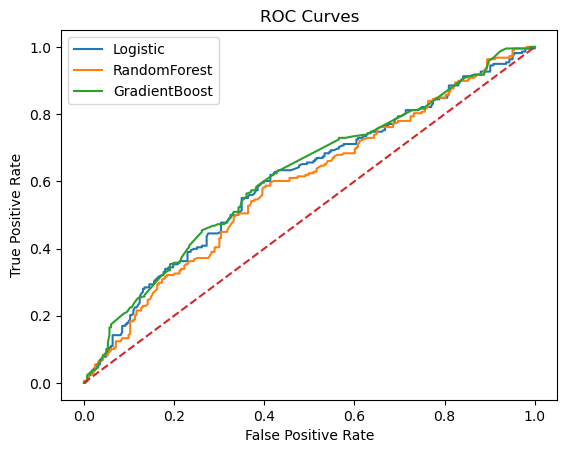

In [ ]:
from sklearn.metrics import roc_curve

for name, model in models.items():
    probs = model.predict_proba(X_val)[:,1]
    fpr, tpr, _ = roc_curve(y_val, probs)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

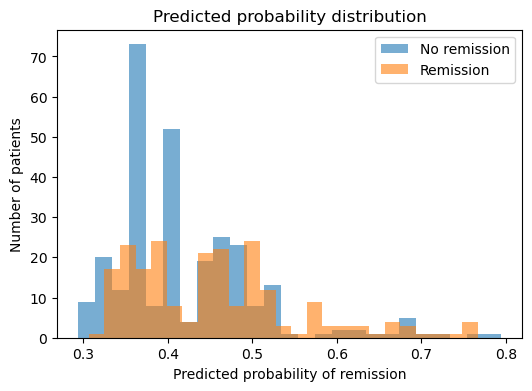

In [ ]:
probs = best_model.predict_proba(X_val)[:,1]

plt.figure(figsize=(6,4))

plt.hist(probs[y_val==0], bins=25, alpha=0.6, label="No remission")
plt.hist(probs[y_val==1], bins=25, alpha=0.6, label="Remission")

plt.xlabel("Predicted probability of remission")
plt.ylabel("Number of patients")
plt.title("Predicted probability distribution")
plt.legend()

plt.show()

In [ ]:
#Classification report on validation data using precision, recall and f1-score for all models + table in latex for master thesis.
from sklearn.metrics import classification_report
for name, model in models.items():
    y_pred = model.predict(X_val)
    print(f"Classification Report for {name}:\n")
    print(classification_report(y_val, y_pred)) 

latex = r"""
\begin{table}[ht]
\centering
\caption{Classification report for the three machine learning models on the validation set.}
\label{tab:classification_report}
\begin{tabular}{lcccc}
\toprule
\textbf{Model} & \textbf{Precision (No)} & \textbf{Recall (No)} & \textbf{Precision (Yes)} & \textbf{Recall (Yes)} \\
\midrule
"""
for name, model in models.items():
    y_pred = model.predict(X_val)
    report = classification_report(y_val, y_pred, output_dict=True)
    precision_no = report["0"]["precision"]
    recall_no = report["0"]["recall"]
    precision_yes = report["1"]["precision"]
    recall_yes = report["1"]["recall"]
    latex += f"{name} & {precision_no:.2f} & {recall_no:.2f} & {precision_yes:.2f} & {recall_yes:.2f} \\\\\n"
latex += r"""
\bottomrule
\end{tabular}
\end{table}
"""
with open("classification_report.tex", "w", encoding="utf-8") as f:
    f.write(latex)
    
    

Classification Report for Logistic:

              precision    recall  f1-score   support

           0       0.62      0.74      0.67       283
           1       0.54      0.40      0.46       218

    accuracy                           0.59       501
   macro avg       0.58      0.57      0.57       501
weighted avg       0.58      0.59      0.58       501

Classification Report for RandomForest:

              precision    recall  f1-score   support

           0       0.63      0.65      0.64       283
           1       0.52      0.50      0.51       218

    accuracy                           0.58       501
   macro avg       0.58      0.58      0.58       501
weighted avg       0.58      0.58      0.58       501

Classification Report for GradientBoost:

              precision    recall  f1-score   support

           0       0.60      0.87      0.71       283
           1       0.60      0.26      0.36       218

    accuracy                           0.60       501
   macro

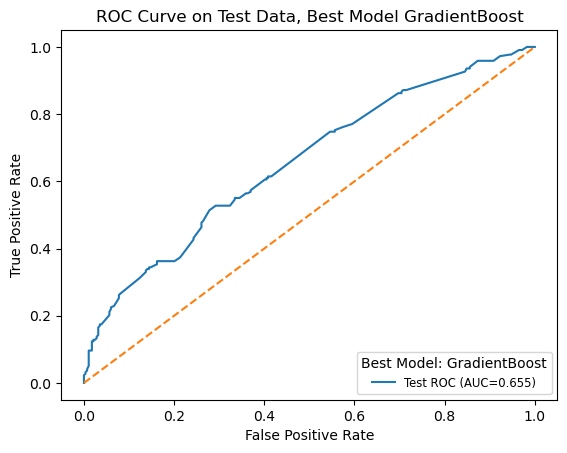

Test AUC for best model GradientBoost: 0.6546


In [ ]:
probs_test = best_model.predict_proba(X_test)[:,1]

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, probs_test)

plt.plot(fpr, tpr, label=f"Test ROC (AUC={roc_auc_score(y_test, probs_test):.3f})")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Data, Best Model " + best_model_name)
#Add legend to show AUC score
plt.legend( loc="lower right", fontsize="small", title="Best Model: " + best_model_name)


plt.show()

print (f"Test AUC for best model {best_model_name}: {roc_auc_score(y_test, probs_test):.4f}")

In [ ]:
#Save model for use in app.py
import pickle as pk

best_model.fit(X_train, y_train)

with open("model.pkl", "wb") as f:
    pk.dump(best_model, f)

In [ ]:
#Print the different 